# 📊 Exploratory Data Analysis (EDA)

## Project Overview

This notebook explores the feature-engineered marketing campaign dataset to identify trends, patterns, relationships, and potential business insights.

The analysis focuses on campaign performance, platform effectiveness, customer reach, profitability, and marketing KPIs.

## Objectives

- Understand campaign distribution
- Analyze campaign performance
- Explore marketing KPIs
- Identify trends and relationships
- Detect outliers
- Generate business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")

In [3]:
# Load feature engineered dataset

df = pd.read_csv(
    "../data/processed/marketing_campaign_feature_engineered.csv"
)

df.head()

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_weekend,country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views,ctr,cpc,cpm,cpa,conversion_rate,roas,roi,revenue_per_click,revenue_per_conversion
0,2023-04-08,2023,4,Apr,14,Sat,7,Spring,0,1,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610,0.83,0.60,5.05,0.00,0.00,0.00,-100.00,0.00,0.00
1,2025-04-28,2025,4,Apr,18,Mon,12,Spring,0,0,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086,0.94,1.28,12.04,0.00,0.00,0.00,-100.00,0.00,0.00
2,2024-12-18,2024,12,Dec,51,Wed,10,Winter,0,0,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0,1.11,0.29,3.26,51.73,0.57,1.86,85.52,0.54,95.96
3,2024-04-26,2024,4,Apr,17,Fri,20,Spring,0,0,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0,0.77,0.66,5.02,0.00,0.00,0.00,-100.00,0.00,0.00
4,2024-04-19,2024,4,Apr,16,Fri,22,Spring,0,0,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160,0.92,0.95,8.75,0.00,0.00,0.00,-100.00,0.00,0.00


In [5]:
df.columns

Index(['date', 'year', 'month', 'month_name', 'week', 'day_of_week',
       'post_hour', 'season', 'is_holiday', 'is_weekend', 'country',
       'market_tier', 'account', 'account_type', 'platform', 'placement',
       'funnel_stage', 'objective', 'theme', 'campaign_id', 'campaign_name',
       'ad_group_id', 'ad_group_name', 'ad_id', 'ad_name', 'spend',
       'impressions', 'reach', 'frequency', 'clicks', 'conversions', 'revenue',
       'video_views', 'ctr', 'cpc', 'cpm', 'cpa', 'conversion_rate', 'roas',
       'roi', 'revenue_per_click', 'revenue_per_conversion'],
      dtype='object')

In [6]:
# Convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

In [7]:
df["date"].dtype

dtype('<M8[ns]')

In [8]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 30000
Columns : 42


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    30000 non-null  datetime64[ns]
 1   year                    30000 non-null  int64         
 2   month                   30000 non-null  int64         
 3   month_name              30000 non-null  object        
 4   week                    30000 non-null  int64         
 5   day_of_week             30000 non-null  object        
 6   post_hour               30000 non-null  int64         
 7   season                  30000 non-null  object        
 8   is_holiday              30000 non-null  int64         
 9   is_weekend              30000 non-null  int64         
 10  country                 30000 non-null  object        
 11  market_tier             30000 non-null  object        
 12  account                 30000 non-null  object

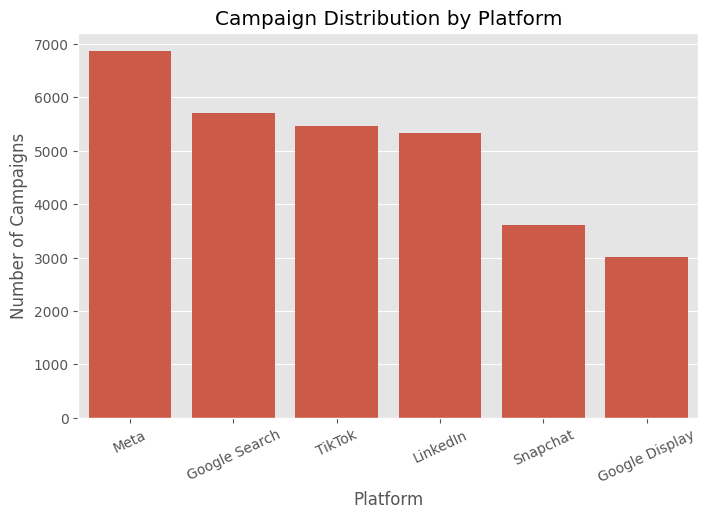

In [10]:
platform_counts = (
    df["platform"]
      .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

plt.title("Campaign Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Campaigns")

plt.xticks(rotation=25)

plt.show()

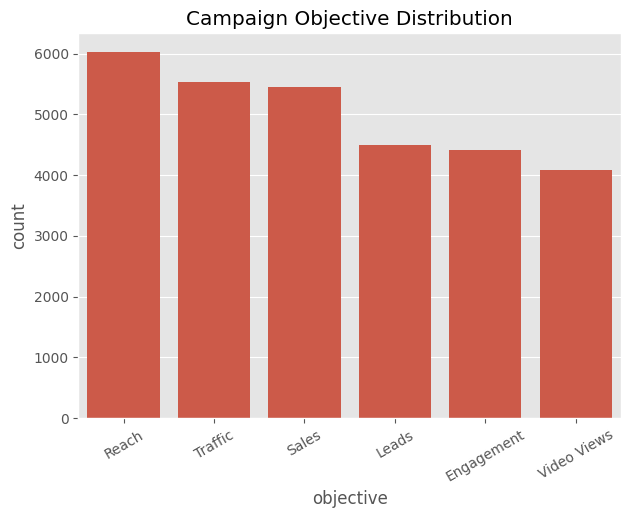

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="objective",
    order=df["objective"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Campaign Objective Distribution")

plt.show()

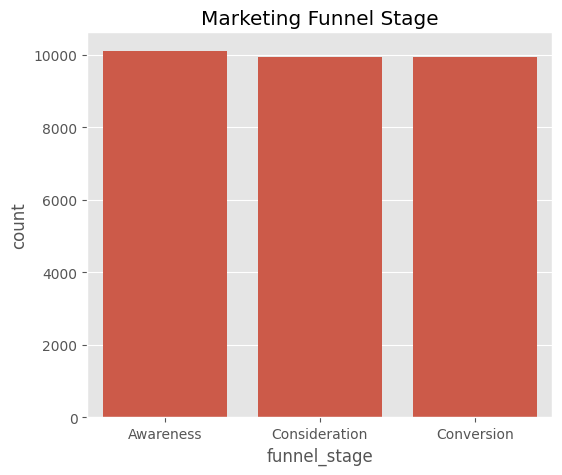

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="funnel_stage",
    order=df["funnel_stage"].value_counts().index
)

plt.title("Marketing Funnel Stage")

plt.show()

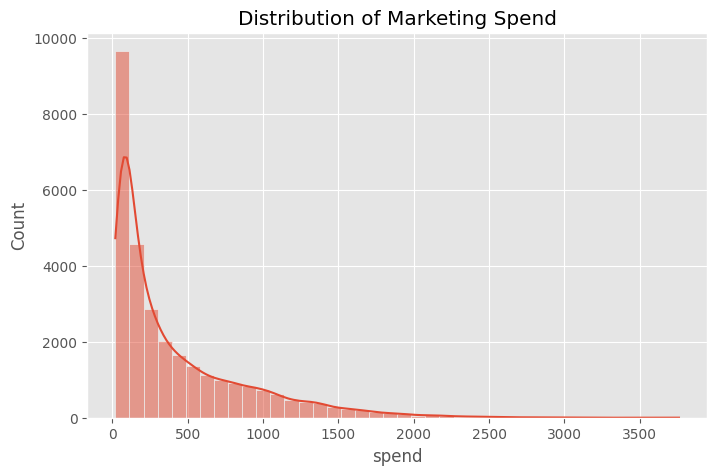

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["spend"],
    bins=40,
    kde=True
)

plt.title("Distribution of Marketing Spend")

plt.show()

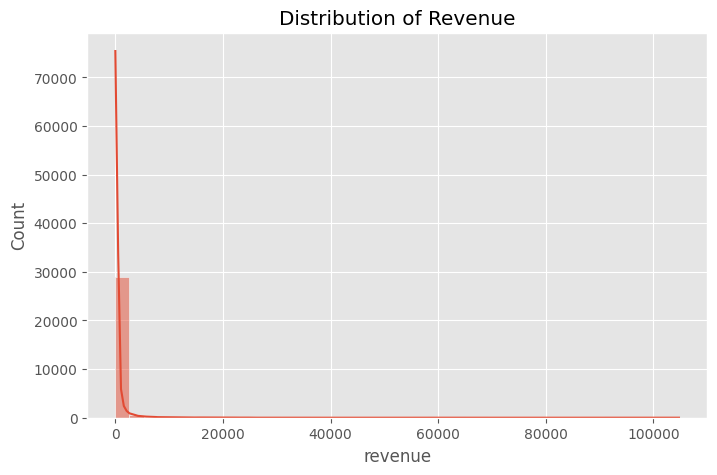

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["revenue"],
    bins=40,
    kde=True
)

plt.title("Distribution of Revenue")

plt.show()

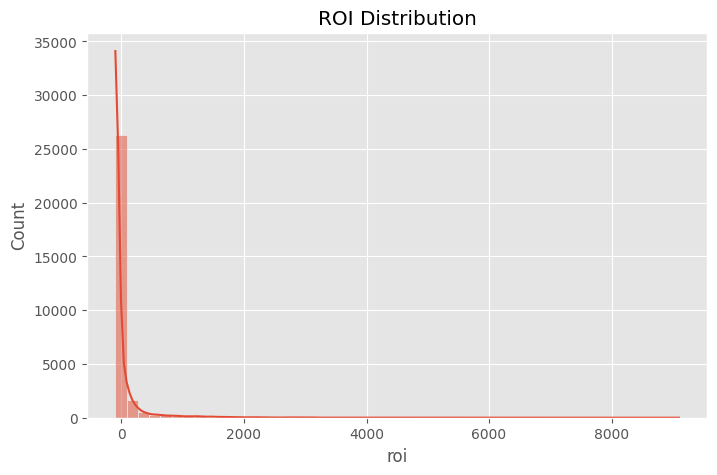

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["roi"],
    bins=50,
    kde=True
)

plt.title("ROI Distribution")

plt.show()

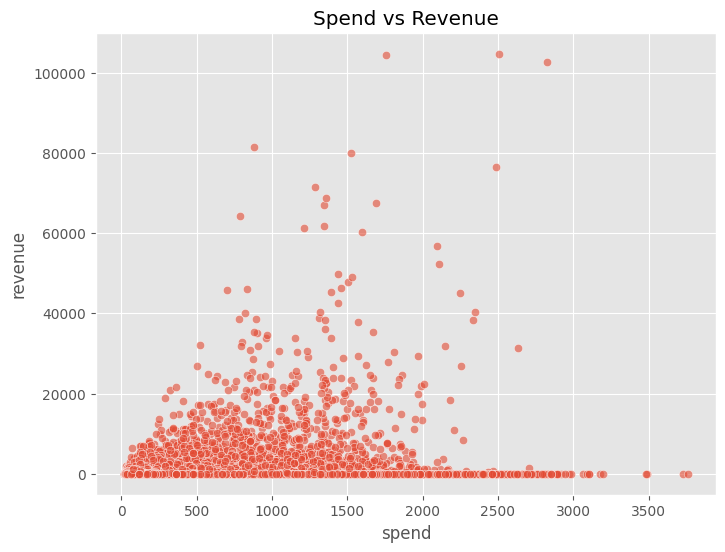

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="spend",
    y="revenue",
    alpha=0.6
)

plt.title("Spend vs Revenue")

plt.show()

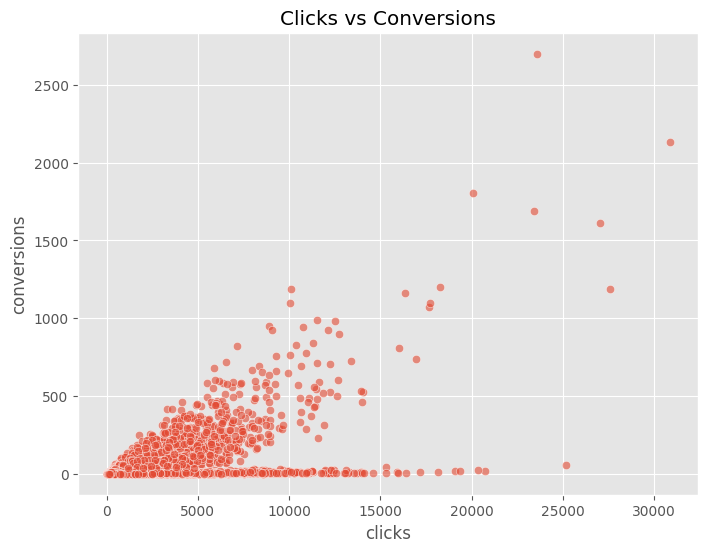

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="clicks",
    y="conversions",
    alpha=0.6
)

plt.title("Clicks vs Conversions")

plt.show()

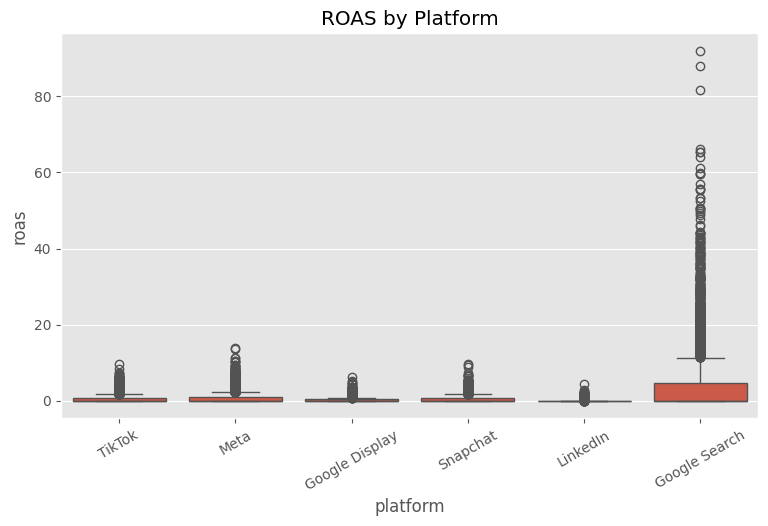

In [18]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="platform",
    y="roas"
)

plt.xticks(rotation=30)

plt.title("ROAS by Platform")

plt.show()

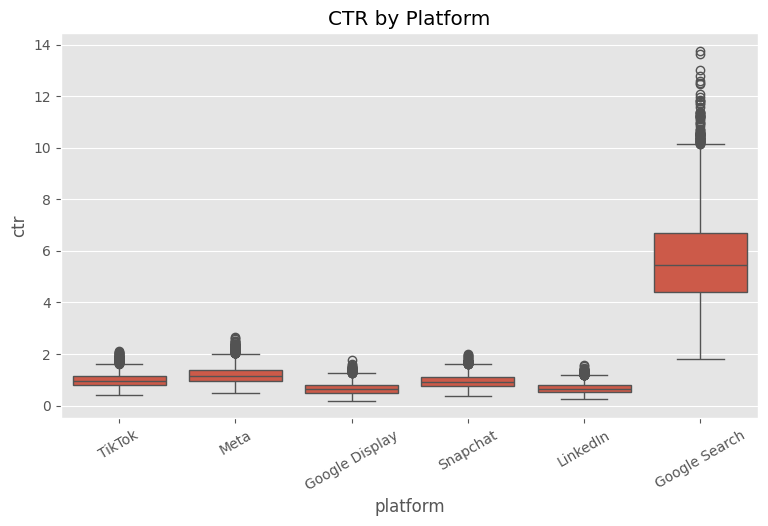

In [19]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="platform",
    y="ctr"
)

plt.xticks(rotation=30)

plt.title("CTR by Platform")

plt.show()

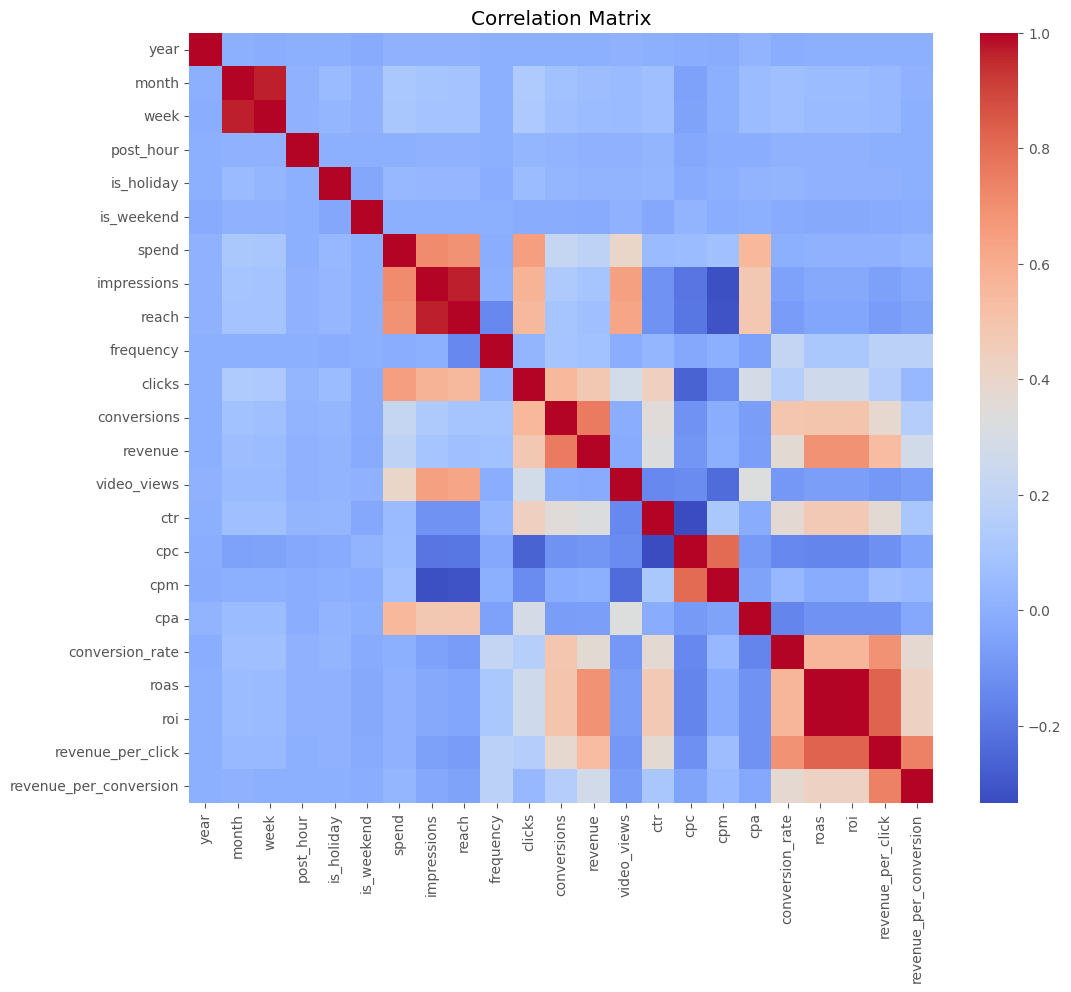

In [20]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

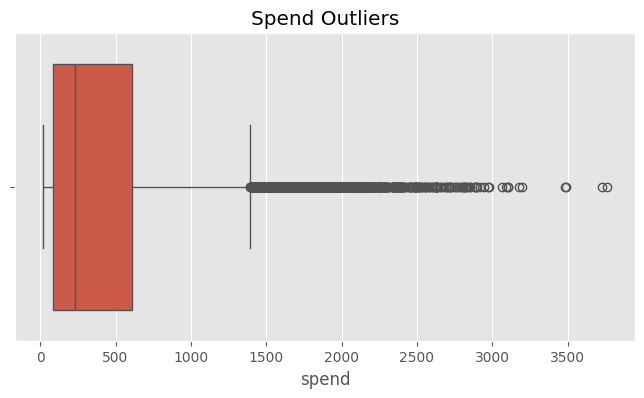

In [21]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["spend"]
)

plt.title("Spend Outliers")

plt.show()

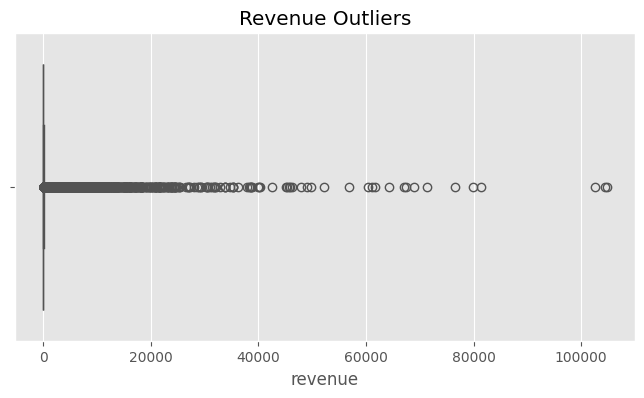

In [22]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["revenue"]
)

plt.title("Revenue Outliers")

plt.show()

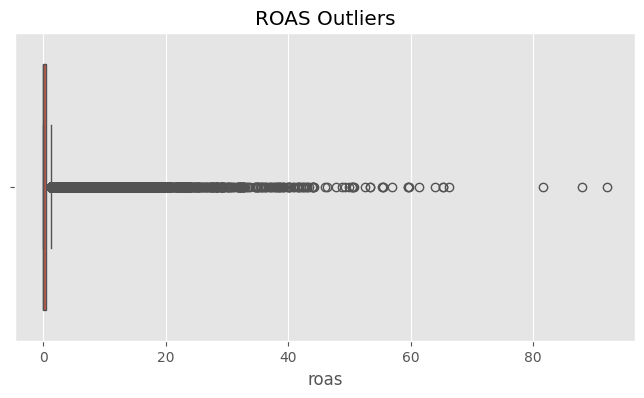

In [23]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["roas"]
)

plt.title("ROAS Outliers")

plt.show()

# Key Findings

### 1. Platform Distribution
- Meta has the highest number of marketing campaigns, making it the most frequently used advertising platform in the dataset.
- Google Search, TikTok, and LinkedIn also have a substantial number of campaigns, enabling meaningful cross-platform comparisons.
- Google Display has the lowest campaign volume among all platforms.

---

### 2. Campaign Objectives
- Reach is the most common campaign objective, indicating a strong focus on brand awareness.
- Traffic and Sales campaigns also contribute significantly to the overall campaign mix.
- Lead Generation, Engagement, and Video View campaigns are comparatively fewer but remain well represented.

---

### 3. Marketing Funnel
- Campaigns are almost evenly distributed across Awareness, Consideration, and Conversion stages.
- This balanced distribution makes the dataset suitable for analyzing performance across the entire marketing funnel.

---

### 4. Spend & Revenue Distribution
- Marketing spend is highly right-skewed, with most campaigns operating on relatively smaller budgets and only a few high-spending campaigns.
- Revenue also follows a right-skewed distribution, indicating that only a small number of campaigns generate exceptionally high revenue.

---

### 5. Campaign Performance
- Higher marketing spend does not always result in higher revenue, suggesting that campaign effectiveness depends on factors beyond budget allocation.
- Clicks and conversions show a positive relationship, although several campaigns generate clicks without achieving meaningful conversions.

---

### 6. Platform Performance
- Google Search exhibits the highest ROAS and CTR among all platforms, indicating stronger advertising efficiency.
- Other platforms display relatively lower median ROAS and CTR, with several high-performing outlier campaigns.

---

### 7. Correlation Analysis
- Spend, impressions, clicks, and reach demonstrate positive relationships, indicating that higher advertising investment generally increases campaign exposure.
- Revenue shows a positive correlation with conversions and ROAS, highlighting the importance of campaign efficiency over spending alone.
- ROI and ROAS exhibit a strong positive relationship since both measure campaign profitability.

---

### 8. Outlier Detection
- Significant outliers exist in Spend, Revenue, and ROAS.
- These high-performing campaigns should not be removed, as they may represent successful real-world marketing campaigns rather than data quality issues.

---

### Overall Conclusion
- The dataset contains campaigns across multiple platforms, objectives, and funnel stages, providing a comprehensive view of digital marketing performance.
- The engineered KPIs effectively capture campaign efficiency, profitability, and conversion performance.
- The dataset is well suited for advanced SQL analysis and interactive Power BI dashboard development.

# Business Questions for SQL Analysis

Based on the exploratory analysis, the following business questions will be answered using SQL:

1. Which advertising platform generated the highest revenue and ROAS?
2. Which campaigns delivered the best ROI?
3. How does campaign performance vary across marketing funnel stages?
4. Which months generated the highest marketing revenue?
5. Which campaign objectives achieved the best conversion rates?
6. Which accounts spent the most on advertising?
7. What are the top-performing campaigns based on revenue and conversions?
8. How do CTR and CPC vary across advertising platforms?
9. Which countries generated the highest campaign revenue?
10. Which platform provides the most cost-efficient marketing performance?